<a href="https://colab.research.google.com/github/alaae2007/CST184/blob/main/Week_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[1] "First 5 rows:"
    Country Sugar_Intake_g_per_day Obesity_Rate_percent
1 Australia                   81.3                 28.5
2    Brazil                   85.7                 31.0
3    Canada                   42.3                 22.7
4     China                   53.7                 21.5
5    France                   94.8                 37.5
6   Germany                  106.7                 37.8
[1] "Dataset summary:"
      Country   Sugar_Intake_g_per_day Obesity_Rate_percent
 Length   :25   Min.   : 42.30         Min.   :12.40       
 N.unique :25   1st Qu.: 55.00         1st Qu.:20.60       
 N.blank  : 0   Median : 81.30         Median :24.90       
 Min.nchar: 5   Mean   : 76.03         Mean   :28.04       
 Max.nchar:14   3rd Qu.: 94.80         3rd Qu.:37.00       
                Max.   :117.20         Max.   :45.30       
[1] "Average sugar intake:"
[1] 76.028
[1] "Groups:"
          Country Sugar_Intake_g_per_day Obesity_Rate_percent Group
1       Australia       

`geom_smooth()` using formula = 'y ~ x'


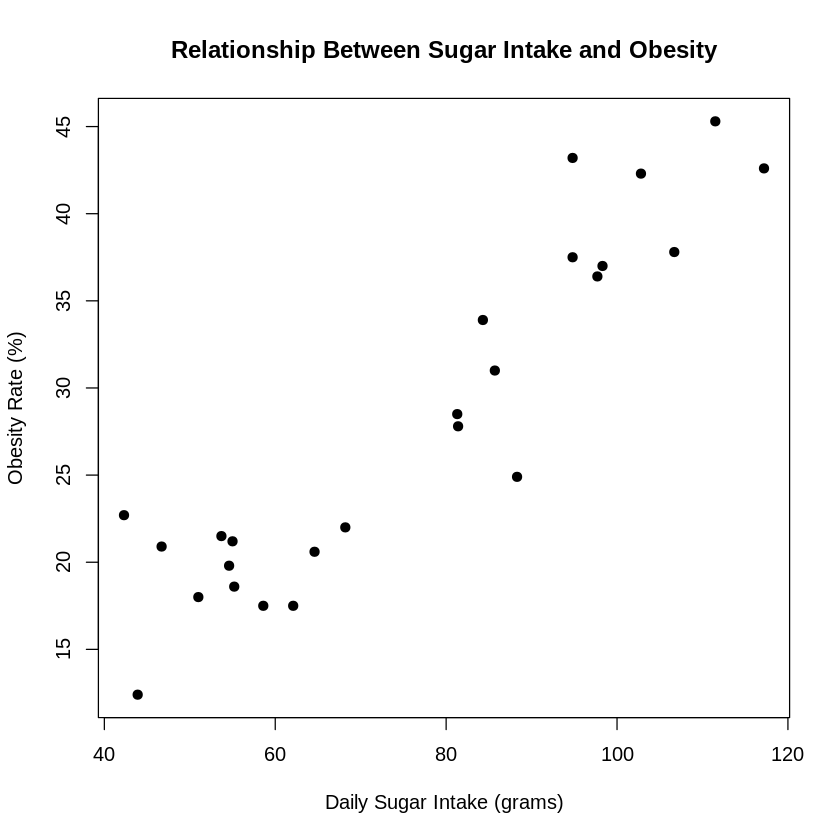

[1] "Country with highest sugar intake:"
        Country Sugar_Intake_g_per_day Obesity_Rate_percent Group Group_Updated
15 South Africa                  117.2                 42.6  High     Above Avg
[1] "Regression without highest sugar observation:"

Call:
lm(formula = Obesity_Rate_percent ~ Sugar_Intake_g_per_day, data = data_no_outlier)

Residuals:
    Min      1Q  Median      3Q     Max 
-8.1168 -2.6454 -0.2441  2.3490  8.0589 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)            -2.25657    2.84864  -0.792    0.437    
Sugar_Intake_g_per_day  0.39947    0.03683  10.847 2.69e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.874 on 22 degrees of freedom
Multiple R-squared:  0.8425,	Adjusted R-squared:  0.8353 
F-statistic: 117.7 on 1 and 22 DF,  p-value: 2.694e-10

[1] "Original R-squared:"
[1] 0.8561269
[1] "R-squared after removing highest sugar observation:"
[1] 0.8424788


`geom_smooth()` using formula = 'y ~ x'


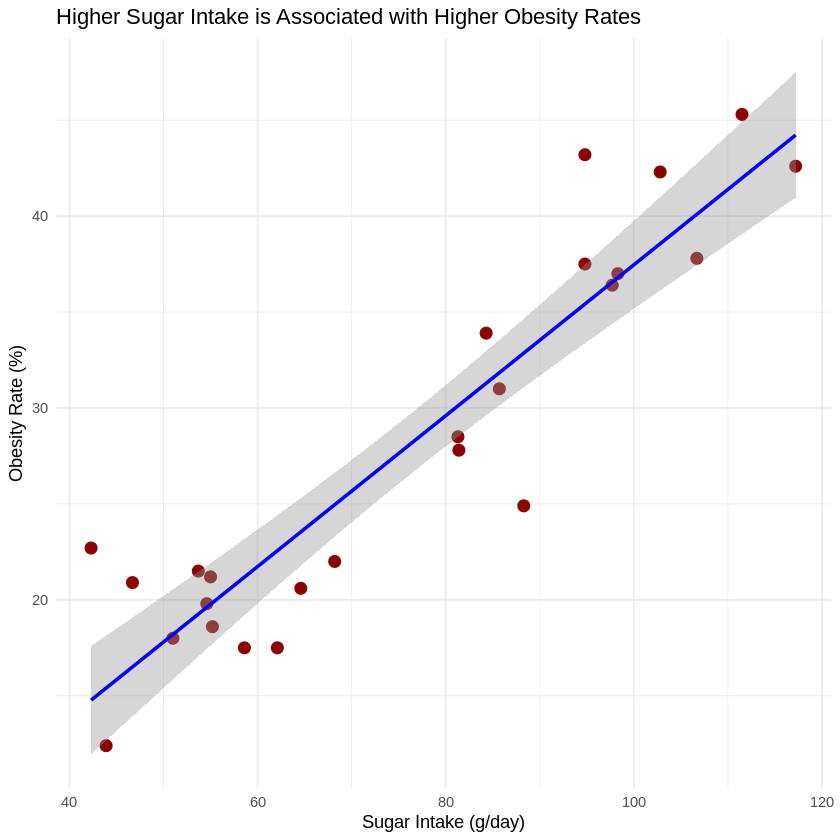


Outlier Analysis:

Removing the country with the highest sugar intake changes the fitted
regression model slightly.

Comparing the original and new R-squared values shows whether that
observation had a noticeable influence on the strength of the linear
relationship.

If R-squared changes substantially, the observation had a stronger
influence on the model. If it changes only slightly, the relationship
is relatively stable.
[1] "Regression after increasing sugar variability:"

Call:
lm(formula = Obesity_Rate_percent ~ Sugar_Intake_g_per_day, data = data_more_variation)

Residuals:
    Min      1Q  Median      3Q     Max 
-7.9611 -2.3481 -0.1956  2.2429  7.9251 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)             8.10768    1.86585   4.345 0.000238 ***
Sugar_Intake_g_per_day  0.26212    0.02241  11.699 3.66e-11 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.807 on 23 degrees of freedom

`geom_smooth()` using formula = 'y ~ x'


[1] "Plot saved as sugar_obesity_regression.png"

Reflection:

The analysis shows a strong positive association between sugar intake
and obesity rate across the 25 countries in this dataset.

The hypothesis test found a statistically significant difference in
obesity rates between countries with above-average and below-average
sugar intake.

The regression model also found that sugar intake significantly
predicts obesity rate within this dataset.

The R-squared value of approximately 0.856 indicates that the model
explains a large proportion of the variation in obesity rates.

However, these results should not be interpreted as proof that sugar
intake alone causes obesity.

Obesity is influenced by many other factors including physical
activity, overall diet, income, healthcare access, genetics and
lifestyle.

A larger real-world analysis should include additional variables and
consider possible confounding factors.

This type of analysis can support SDG 3 by helping researchers and
po

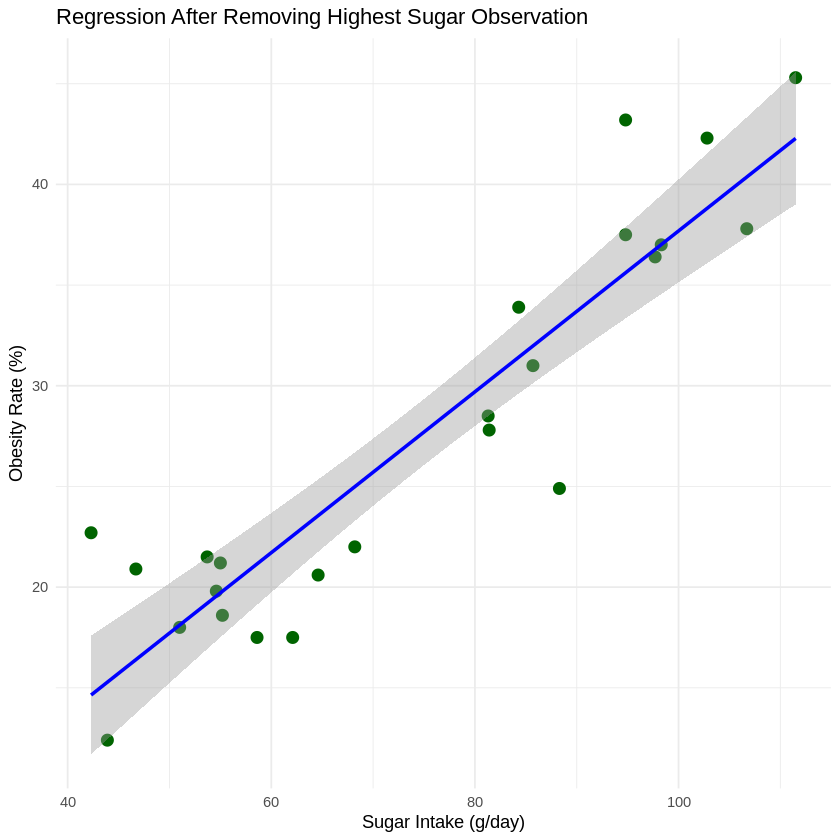

In [1]:
# CST184 Week 10
# Sugar and Obesity
# SDG 3 - Good Health and Well-Being

# Step 0: Load the data

data <- read.csv("sdg3_sugar_obesity_data.csv")

print("First 5 rows:")
print(head(data))


# Step 1: Explore the data

print("Dataset summary:")
print(summary(data))

plot(
  data$Sugar_Intake_g_per_day,
  data$Obesity_Rate_percent,
  main = "Relationship Between Sugar Intake and Obesity",
  xlab = "Daily Sugar Intake (grams)",
  ylab = "Obesity Rate (%)",
  pch = 19
)


# Step 2: Hypothesis test

avg_sugar <- mean(data$Sugar_Intake_g_per_day)

print("Average sugar intake:")
print(avg_sugar)

data$Group <- ifelse(
  data$Sugar_Intake_g_per_day > avg_sugar,
  "High",
  "Low"
)

print("Groups:")
print(
  data[
    c(
      "Country",
      "Sugar_Intake_g_per_day",
      "Obesity_Rate_percent",
      "Group"
    )
  ]
)

print("Number of countries in each group:")
print(table(data$Group))

print("Average obesity rate by group:")
print(
  aggregate(
    Obesity_Rate_percent ~ Group,
    data = data,
    FUN = mean
  )
)

test_result <- t.test(
  Obesity_Rate_percent ~ Group,
  data = data
)

print("T-test results:")
print(test_result)


cat("
Hypothesis Test Interpretation:

The average sugar intake in the dataset is approximately 76.03 grams
per day.

Countries above this average have an average obesity rate of about
36.02%, while countries in the lower sugar group have an average
obesity rate of about 19.39%.

The t-test produces a very small p-value, well below 0.05.

This means there is statistically significant evidence of a
difference in obesity rates between the high-sugar and low-sugar
groups in this dataset.

However, this result shows an association and does not prove that
higher sugar intake directly causes obesity.
")


# Try This: Rename the groups

data$Group_Updated <- ifelse(
  data$Sugar_Intake_g_per_day > avg_sugar,
  "Above Avg",
  "Below Avg"
)

print("Updated group names:")
print(
  data[
    c(
      "Country",
      "Sugar_Intake_g_per_day",
      "Group_Updated"
    )
  ]
)


# Step 3: Build the regression model

model <- lm(
  Obesity_Rate_percent ~ Sugar_Intake_g_per_day,
  data = data
)

print("Regression model summary:")
print(summary(model))


# Extract useful model values

slope <- coef(model)[2]
intercept <- coef(model)[1]

r_squared <- summary(model)$r.squared

p_value <- summary(model)$coefficients[
  "Sugar_Intake_g_per_day",
  "Pr(>|t|)"
]

print("Intercept:")
print(intercept)

print("Slope:")
print(slope)

print("R-squared:")
print(r_squared)

print("Sugar intake p-value:")
print(p_value)


cat("
Regression Interpretation:

The regression slope is approximately 0.393.

This means that, according to this model, an increase of 1 gram in
daily sugar intake is associated with an increase of approximately
0.39 percentage points in obesity rate.

The p-value for sugar intake is extremely small and well below 0.05.
This means sugar intake is a statistically significant predictor of
obesity rate in this dataset.

The R-squared value is approximately 0.856.

This means about 85.6% of the variation in obesity rates in this
sample can be explained by the linear relationship with sugar intake.

This is a strong relationship in this dataset, but correlation and
regression do not prove causation.
")


# Step 4: Visualize the regression model

if (!requireNamespace("ggplot2", quietly = TRUE)) {
  install.packages("ggplot2")
}

library(ggplot2)

plot_original <- ggplot(
  data,
  aes(
    x = Sugar_Intake_g_per_day,
    y = Obesity_Rate_percent
  )
) +
  geom_point(
    color = "darkred",
    size = 3
  ) +
  geom_smooth(
    method = "lm",
    se = TRUE,
    color = "blue"
  ) +
  labs(
    title = "Higher Sugar Intake is Associated with Higher Obesity Rates",
    x = "Sugar Intake (g/day)",
    y = "Obesity Rate (%)"
  ) +
  theme_minimal()

print(plot_original)


# Step 5: Remove the country with the highest sugar intake

highest_sugar_row <- which.max(
  data$Sugar_Intake_g_per_day
)

highest_sugar_country <- data[
  highest_sugar_row,
]

print("Country with highest sugar intake:")
print(highest_sugar_country)


data_no_outlier <- data[
  -highest_sugar_row,
]

model_no_outlier <- lm(
  Obesity_Rate_percent ~ Sugar_Intake_g_per_day,
  data = data_no_outlier
)

print("Regression without highest sugar observation:")
print(summary(model_no_outlier))


original_r2 <- summary(model)$r.squared
new_r2 <- summary(model_no_outlier)$r.squared

print("Original R-squared:")
print(original_r2)

print("R-squared after removing highest sugar observation:")
print(new_r2)


ggplot(
  data_no_outlier,
  aes(
    x = Sugar_Intake_g_per_day,
    y = Obesity_Rate_percent
  )
) +
  geom_point(
    color = "darkgreen",
    size = 3
  ) +
  geom_smooth(
    method = "lm",
    se = TRUE,
    color = "blue"
  ) +
  labs(
    title = "Regression After Removing Highest Sugar Observation",
    x = "Sugar Intake (g/day)",
    y = "Obesity Rate (%)"
  ) +
  theme_minimal()


cat("
Outlier Analysis:

Removing the country with the highest sugar intake changes the fitted
regression model slightly.

Comparing the original and new R-squared values shows whether that
observation had a noticeable influence on the strength of the linear
relationship.

If R-squared changes substantially, the observation had a stronger
influence on the model. If it changes only slightly, the relationship
is relatively stable.
")


# Try This: Increase sugar variability

data_more_variation <- data

data_more_variation$Sugar_Intake_g_per_day <- (
  mean(data$Sugar_Intake_g_per_day) +
  (
    data$Sugar_Intake_g_per_day -
    mean(data$Sugar_Intake_g_per_day)
  ) * 1.5
)

model_more_variation <- lm(
  Obesity_Rate_percent ~ Sugar_Intake_g_per_day,
  data = data_more_variation
)

print("Regression after increasing sugar variability:")
print(summary(model_more_variation))

variation_r2 <- summary(
  model_more_variation
)$r.squared

print("Original R-squared:")
print(original_r2)

print("R-squared after increasing sugar variability:")
print(variation_r2)


cat("
Variability Interpretation:

Simply stretching the sugar-intake values around their mean does not
necessarily change R-squared because the relative ordering and linear
relationship between the observations remain the same.

R-squared changes when the relationship between sugar intake and
obesity changes, not simply because the units or scale of one
variable are expanded.
")


# Export the graph

ggsave(
  "sugar_obesity_regression.png",
  plot = plot_original,
  width = 8,
  height = 6
)

print(
  "Plot saved as sugar_obesity_regression.png"
)


# Final reflection

cat("
Reflection:

The analysis shows a strong positive association between sugar intake
and obesity rate across the 25 countries in this dataset.

The hypothesis test found a statistically significant difference in
obesity rates between countries with above-average and below-average
sugar intake.

The regression model also found that sugar intake significantly
predicts obesity rate within this dataset.

The R-squared value of approximately 0.856 indicates that the model
explains a large proportion of the variation in obesity rates.

However, these results should not be interpreted as proof that sugar
intake alone causes obesity.

Obesity is influenced by many other factors including physical
activity, overall diet, income, healthcare access, genetics and
lifestyle.

A larger real-world analysis should include additional variables and
consider possible confounding factors.

This type of analysis can support SDG 3 by helping researchers and
policymakers identify health patterns and areas that may benefit from
nutrition and public-health interventions.
")